# Caltrans Wide Octagon

In [ ]:
from xsection import PolygonShape
from xsection.confined import ConfinedSection
from xsection.library import Circle
import xara 
import veux
import math
import numpy as np


import xara.units.iks as units

In [ ]:

def WideOctagon(Dcol, Wcol, nLbar, nLbar2, DLbar, DLbar2, sTbar, units, materials):
    """
    Geometric analogue of the OpenSees BuildWideOctColSection.

    Parameters
    ----------
    Dcol, Wcol : float
        Short and long flat-to-flat dimensions of the wide octagon.
    nLbar, nLbar2 : int
        Number of outer and inner longitudinal bars.
    DLbar, DLbar2 : float
        Diameters of outer and inner longitudinal bars.
    sTbar : float
        Transverse spiral spacing. Included for signature compatibility.
        It affects confinement in OpenSees, but not the plan geometry here.
    units : object
        Unit namespace, expected to provide units.inch.
    materials : dict
        Must contain "cover", "core", and "steel".

    Returns
    -------
    CompositeSection
    """
    # geometry only; transverse spacing affects confinement, not plan shape
    _ = sTbar

    if Dcol <= 0 or Wcol <= 0:
        raise ValueError("Dcol and Wcol must be positive.")
    if Wcol < Dcol:
        raise ValueError("Wcol must satisfy Wcol >= Dcol.")

    if int(nLbar) != nLbar or int(nLbar2) != nLbar2:
        raise ValueError("nLbar and nLbar2 must be integers.")
    nLbar = int(nLbar)
    nLbar2 = int(nLbar2)

    if nLbar % 2 != 0 or nLbar2 % 2 != 0:
        raise ValueError("nLbar and nLbar2 must be even.")

    cover = 2.0 * units.inch          # from the OpenSees section
    DTbar = 0.625 * units.inch        # #5 spiral bar diameter

    Rcol = Dcol / 2.0
    spO = (Wcol - Dcol) / 2.0

    Dcore = Dcol - 2.0 * cover
    if Dcore <= 0:
        raise ValueError("Cover is too large for the given Dcol.")

    Rcore = Dcore / 2.0

    # OpenSees bar radius:
    # Dlong = Dcore - 2*DTbar - DLbar
    Dlong = Dcore - 2.0 * DTbar - DLbar
    if Dlong <= 0:
        raise ValueError("Longitudinal bar ring radius is non-positive.")
    Rlong = Dlong / 2.0

    def wide_octagon_vertices(D, W):
        """
        Exact outer wide-octagon implied by the OpenSees offsets.
        CCW ordering.
        """
        a = D / 2.0
        s = (W - D) / 2.0
        b = a * math.tan(math.pi / 8.0)

        return [
            (-s - b,  a),
            (-s - a,  b),
            (-s - a, -b),
            (-s - b, -a),
            ( s + b, -a),
            ( s + a, -b),
            ( s + a,  b),
            ( s + b,  a),
        ]

    def stadium_vertices(radius, half_span, n_arc=24):
        """
        Polygonal approximation of the OpenSees core:
        left semicircle + bottom chord + right semicircle + top chord.
        CCW ordering.
        """
        left_arc = np.linspace(math.pi / 2.0, 3.0 * math.pi / 2.0, n_arc, endpoint=True)
        right_arc = np.linspace(3.0 * math.pi / 2.0, 5.0 * math.pi / 2.0, n_arc, endpoint=True)

        pts = [(-half_span + radius * math.cos(t), radius * math.sin(t)) for t in left_arc]
        pts += [( half_span + radius * math.cos(t), radius * math.sin(t)) for t in right_arc]
        return pts

    def arc_bars(proto, center_y, center_z, radius, nbar, start_deg, end_deg):
        """
        Place bar circles along an arc.
        endpoint=False matches the usual OpenSees layer circ convention:
        no duplicate terminal point on a closed/full sweep.
        """
        if nbar <= 0:
            return []

        ang = np.deg2rad(np.linspace(start_deg, end_deg, nbar, endpoint=False))
        return [
            proto.translate([center_y + radius * math.cos(a),
                             center_z + radius * math.sin(a)])
            for a in ang
        ]

    outer_vertices = wide_octagon_vertices(Dcol, Wcol)
    core_vertices = stadium_vertices(Rcore, spO, n_arc=24)

    cover_shape = PolygonShape(
        exterior=outer_vertices,
        interior=[core_vertices[::-1]],   # hole orientation opposite the exterior
        mesh_size=cover / 2.0,
        material=materials["cover"],
        group="cover",
        z=0,
        mesh_type="T3",
    )

    core_shape = PolygonShape(
        exterior=core_vertices,
        mesh_size=Dcore / 10.0,
        material=materials["core"],
        group="core",
        z=1,
        mesh_type="T3",
    )

    outer_bar = Circle(
        DLbar / 2.0,
        z=2,
        mesh_scale=1 / 2,
        divisions=8,
        material=materials["steel"],
        group="steel",
        mesh_type="T3",
    )

    inner_bar = Circle(
        DLbar2 / 2.0,
        z=2,
        mesh_scale=1 / 2,
        divisions=8,
        material=materials["steel"],
        group="steel",
        mesh_type="T3",
    )

    n_outer_side = nLbar // 2
    n_inner_side = nLbar2 // 2

    bars = []
    # Match the four OpenSees layer circ commands
    bars += arc_bars(outer_bar, -spO, 0.0, Rlong, n_outer_side,  45.0, 315.0)
    bars += arc_bars(outer_bar, +spO, 0.0, Rlong, n_outer_side, 225.0, 495.0)
    bars += arc_bars(inner_bar, -spO, 0.0, Rlong, n_inner_side, 315.0, 405.0)
    bars += arc_bars(inner_bar, +spO, 0.0, Rlong, n_inner_side, 135.0, 225.0)

    return ConfinedSection(cover=cover_shape, 
                           core=core_shape, steel=bars)

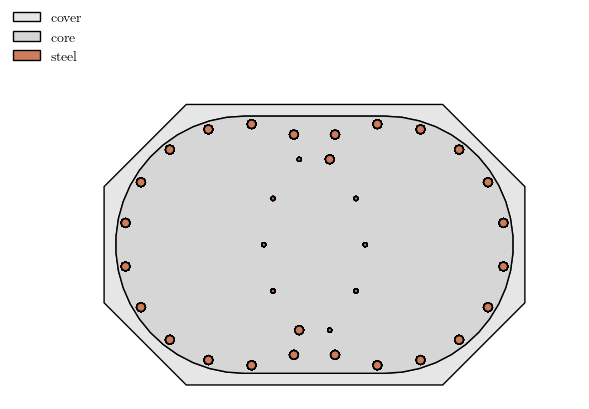

In [ ]:
class _: pass
self = _()

self.fy = 60.0*units.ksi   # ksi
self.Es = 30e3*units.ksi
self.Gs = self.Es / (2*(1+0.3))

self.fc_unconf = 4.0*units.ksi   # unconfined concrete
self.fc_conf   = 5.0*units.ksi  # confined concrete

self.poisson = 0.24

self.Ec = 57.0 * math.sqrt(self.fc_unconf/units.psi)*units.ksi
self.Gc = self.Ec / (2*(1+self.poisson))

materials = {
    "core":  xara.Material(E=self.Ec, G=self.Gc, fc=self.fc_conf, type="Concrete01", tag=1),
    "cover": xara.Material(E=self.Ec, G=self.Gc, fc=self.fc_unconf, type="Concrete01", tag=2),
    "steel": xara.Material(E=self.Es, G=self.Gs, Fy=self.fy, b=0.02, type="Steel01", tag=3)
}

shape = WideOctagon(Dcol=48, 
                    nLbar=26, 
                    DLbar=1.410,
                    sTbar = 3.5, 
                    DLbar2 = 0.625, 
                    nLbar2=8, Wcol=72, 
                    units=units,
                    materials=materials)

veux.draw_shape(shape)